# Per-scale convergence toward the equilibrium z*

## Background

MDEQ has no fixed number of layers, instead, its internal representation is defined as the solution `z*` of a fixed-point equation `f(z*) = z*`, found iteratively by the **Broyden solver** (up to `F_THRES` iterations per frame).

The companion report, `analisis_resultados.ipynb`, found that **scale 1 is by far the most important of MDEQ's 4 multiscale branches to warm-start** in streaming inference (roughly 5x as important as scale 0). This notebook asks a follow-up question, using a single validation image and no streaming at all (`DEQ.MODE=baseline`, cold start every call): **does scale 1 matter because it's also the slowest scale to converge to its own equilibrium?** If it were, that would be a simple, direct explanation for the sweep's finding.

A companion notebook, `convergence_population_analysis.ipynb`, repeats the same measurements below across all 500 validation images to check whether the single-image findings generalize.

## Roadmap

1. **Sections 1-5** — load the model and one image, run the solver to full convergence (`f_thres=27`), and save the resulting z\*.
2. **Sections 6-8** — three additional properties of z\* worth knowing before the main question: which features influence the final prediction most (Section 6), how locally stable the equilibrium is (Section 7), and what a convergence error looks like spatially (Section 8).
3. **Sections 9-14** — the main question: re-run the solver at every budget from `f_thres=1` to `27` and measure, per channel and per scale, how far each one still is from z\* at each step.

## 1. Setup: GPU, paths, imports

`CUDA_VISIBLE_DEVICES` must be set **before** `import torch`, so it's the very first thing in this notebook. (Reproducibility across runs was checked directly (see the closing technical notes) and confirmed to need no special cuDNN settings, so setup here matches plain PyTorch/project defaults.)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys
from pathlib import Path

import numpy as np
import torch

# This notebook lives in MDEQ-Vision/results/ml_project/, but lib/models/mdeq.py
# itself does `sys.path.append("lib/models")` / `sys.path.append("../")` relative
# to the process's current working directory (not to __file__), matching how
# tools/seg_test.py is always run with cwd == MDEQ-Vision/. So we chdir there
# first, exactly like every other script in this project does implicitly.
MDEQ_VISION_ROOT = Path("../..").resolve()
assert (MDEQ_VISION_ROOT / "lib").is_dir(), f"expected lib/ at {MDEQ_VISION_ROOT / 'lib'}"
os.chdir(MDEQ_VISION_ROOT)
sys.path.insert(0, "lib")  # same as tools/_init_paths.py

import models
import datasets
from config import config

print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
print("cwd:", os.getcwd())

torch 2.4.1 | cuda available: True
cwd: /home/sjansasoy/StreamDEQ-2/streamdeq-code/Cityscapes/MDEQ-Vision


## 2. Load config, build the model, load pretrained weights

Reusing `experiments/cityscapes/baseline/seg_mdeq_XL_sf_27i.yaml` as-is: `DEQ.MODE: baseline` (no streaming, cold start every call, exactly what we want for a single well-defined z*), `DEQ.F_THRES: 27` (the existing single-frame convergence baseline), `TEST_SET: val.lst` (plain validation list, no priming frames needed since we're not streaming).

Skipping `nn.DataParallel` here (unlike `tools/seg_test.py`) since we only need one GPU and want direct access to the model's own methods (`_forward`, `segment`) without going through `.module.`.

In [2]:
CFG_PATH = "experiments/cityscapes/baseline/seg_mdeq_XL_sf_27i.yaml"

config.defrost()
config.merge_from_file(CFG_PATH)
config.freeze()

print("DEQ.MODE:", config.DEQ.MODE)
print("DEQ.F_THRES:", config.DEQ.F_THRES)
print("DATASET.TEST_SET:", config.DATASET.TEST_SET)
print("TEST.MODEL_FILE:", config.TEST.MODEL_FILE)

model = eval("models." + config.MODEL.NAME + ".get_seg_net")(config)

model_state_file = config.TEST.MODEL_FILE
pretrained_dict = torch.load(model_state_file, map_location="cpu")
model_dict = model.state_dict()
pretrained_dict = {k[6:]: v for k, v in pretrained_dict.items() if k[6:] in model_dict.keys()}
print(f"loaded {len(pretrained_dict)} / {len(model_dict)} tensors from checkpoint")
model_dict.update(pretrained_dict)
model.load_state_dict(model_dict)

model = model.cuda().eval()
print("model ready on", next(model.parameters()).device)

DEQ.MODE: baseline
DEQ.F_THRES: 27
DATASET.TEST_SET: list/cityscapes/val.lst
TEST.MODEL_FILE: pretrained_models/MDEQ_XL_Seg.pkl


/tmp/ipykernel_3359698/3181088893.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict = torch.load(model_state_file, map_location="cpu")


loaded 131 / 131 tensors from checkpoint


model ready on cuda:0


## 3. Load one validation image

Same `Cityscapes` dataset class and constructor arguments `tools/seg_test.py` uses, just wrapped in a `DataLoader` with `batch_size=1` so the collation (numpy -> batched tensor) matches production exactly, and we only pull the first batch instead of iterating the whole validation set.

In [3]:
test_size = (config.TEST.IMAGE_SIZE[1], config.TEST.IMAGE_SIZE[0])
test_dataset = eval("datasets." + config.DATASET.DATASET)(
    root=config.DATASET.ROOT,
    list_path=config.DATASET.TEST_SET,
    num_samples=None,
    num_classes=config.DATASET.NUM_CLASSES,
    multi_scale=False,
    flip=False,
    ignore_label=config.TRAIN.IGNORE_LABEL,
    base_size=config.TEST.BASE_SIZE,
    crop_size=test_size,
    downsample_rate=1,
)
print(f"{len(test_dataset)} images in {config.DATASET.TEST_SET}")

testloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True
)

IMAGE_INDEX = 0
image, label, size, name = next(iter(testloader))
print("name:", name)
print("image tensor:", image.shape, image.dtype)
print("label tensor:", label.shape, label.dtype)
print("original size (H, W):", size)

500 images in list/cityscapes/val.lst


name: ['frankfurt_000000_000294_leftImg8bit']
image tensor: torch.Size([1, 3, 1024, 2048]) torch.float32
label tensor: torch.Size([1, 1024, 2048]) torch.int32
original size (H, W): tensor([[1024, 2048,    3]])


## 4. Run a fully-converged forward pass to get z*

Calling `model._forward(...)` directly (bypassing `forward()`) is what gives us the raw multiscale state instead of the already-segmented class logits — see Diagram 1 in the appendix of `analisis_resultados.ipynb`. `[image, None]` matches how `mode='baseline'` calls it internally (`None` = cold start, no streaming state).

In [4]:
image_gpu = image.cuda()

with torch.no_grad():
    z_star, jac_loss, sradius = model._forward(
        [image_gpu, None],
        train_step=-1,
        compute_jac_loss=False,
        f_thres=config.DEQ.F_THRES,
    )

print(f"z* is a {type(z_star).__name__} with {len(z_star)} scales\n")
total_elems = 0
for i, z in enumerate(z_star):
    n = z.numel()
    total_elems += n
    print(f"  scale {i}: shape={tuple(z.shape)}  dtype={z.dtype}  device={z.device}  "
          f"mean={z.mean().item(): .4f}  std={z.std().item():.4f}")
print(f"\ntotal elements: {total_elems:,}  (~{total_elems * 4 / 1e6:.1f} MB in float32)")

z* is a list with 4 scales

  scale 0: shape=(1, 88, 256, 512)  dtype=torch.float32  device=cuda:0  mean=-0.0026  std=0.0682
  scale 1: shape=(1, 176, 128, 256)  dtype=torch.float32  device=cuda:0  mean=-0.0037  std=0.0496
  scale 2: shape=(1, 352, 64, 128)  dtype=torch.float32  device=cuda:0  mean=-0.0020  std=0.0449
  scale 3: shape=(1, 704, 32, 64)  dtype=torch.float32  device=cuda:0  mean=-0.0047  std=0.0357

total elements: 21,626,880  (~86.5 MB in float32)


## 5. Save z* and verify the round trip

`torch.save` handles a plain Python list of tensors directly; no special handling needed. Moving to CPU first avoids a device-mismatch surprise later if this is reloaded in a session without a GPU, or with a different `CUDA_VISIBLE_DEVICES` mapping (as will happen here: this notebook's "cuda:0" is physically GPU 1).

Cached under `results/ml_project/z_star_cache/frame_t/`, one file per image (~86 MB each) — `frame_t/` holds equilibria of labeled evaluation frames; a sibling `frame_t_minus_1/` folder (used in `fusion_contamination.ipynb`) holds equilibria of real preceding video frames, kept separate so it's always clear which frame a cached z* belongs to.

In [5]:
Z_STAR_DIR = Path("results/ml_project/z_star_cache/frame_t")
Z_STAR_DIR.mkdir(parents=True, exist_ok=True)

image_name = name[0]
z_star_path = Z_STAR_DIR / f"{image_name}_f{config.DEQ.F_THRES}_z_star.pt"

z_star_cpu = [z.detach().cpu() for z in z_star]
torch.save(z_star_cpu, z_star_path)
print(f"saved to {z_star_path} ({z_star_path.stat().st_size / 1e6:.1f} MB)")

z_star_reloaded = torch.load(z_star_path, map_location="cpu")
matches = [torch.equal(a, b) for a, b in zip(z_star_cpu, z_star_reloaded)]
print("round-trip identical per scale:", matches)

saved to results/ml_project/z_star_cache/frame_t/frankfurt_000000_000294_leftImg8bit_f27_z_star.pt (86.5 MB)
round-trip identical per scale: [True, True, True, True]


/tmp/ipykernel_3359698/3303540594.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_star_reloaded = torch.load(z_star_path, map_location="cpu")


## 6. How much does each feature influence the final segmentation?

`segment()` concatenates the 4 scales into one 1320-channel tensor (88 + 176 + 352 + 704) in the exact same order used everywhere else in this project (scale 0 first, scale 3 last — the same order `list2vec`/`vec2list` use), then feeds it through `last_layer`, whose first op is a 1x1 conv `Conv2d(1320, 1320)`. For a 1x1 conv, output channel `o` is just a weighted sum over all 1320 input channels: `out[o] = sum_c weight[o, c] * in[c]`. So the L2 norm of `weight[:, c]` (over all output channels `o`, for a fixed input channel `c`) is a direct measure of how much that one feature can move the final prediction, independent of anything about convergence speed.

This lets us ask: are the features in scale 1 (the scale we already found to matter most for warm-starting) also the ones the segmentation head listens to most?

In [6]:
SCALE_CHANNELS = [z.shape[1] for z in z_star]  # [88, 176, 352, 704], in concat order
boundaries = np.cumsum([0] + SCALE_CHANNELS)  # [0, 88, 264, 616, 1320]

first_conv = model.last_layer[0]
assert first_conv.weight.shape[1] == sum(SCALE_CHANNELS), "in_channels should equal total feature count"

# Weight-based influence: L2 norm, over output channels, of each input channel's weight column.
influence = first_conv.weight.detach()[:, :, 0, 0].norm(dim=0).cpu()  # shape (1320,)
# Weight alone ignores how large the activation typically is; multiplying by
# each channel's std at z* gives a more realistic "expected contribution".
activation_std = torch.cat([z.detach().cpu().std(dim=(0, 2, 3)) for z in z_star])
contribution = influence * activation_std

scale_influence = [influence[boundaries[i]:boundaries[i + 1]] for i in range(4)]
total_contribution = contribution.sum().item()

print(f"{'scale':>6} {'#feat':>6} {'mean weight':>12} {'mean contrib':>13} {'% of total':>11}")
for i in range(4):
    c = contribution[boundaries[i]:boundaries[i + 1]]
    print(f"{i:>6} {len(scale_influence[i]):>6} {scale_influence[i].mean().item():>12.4f} "
          f"{c.mean().item():>13.5f} {100 * c.sum().item() / total_contribution:>10.1f}%")

 scale  #feat  mean weight  mean contrib  % of total
     0     88       0.1332       0.00823       12.5%
     1    176       0.1251       0.00551       16.7%
     2    352       0.1239       0.00469       28.4%
     3    704       0.1163       0.00350       42.4%


Per-channel, scale 0 has the highest average pull (`mean weight`) — the opposite of "scale 1 matters most". But scale 3 has 8x more channels than scale 0, so its **total** share (`% of total`) is actually the largest (42%), while scale 1 is only 17%. Neither view puts scale 1 on top, and that's expected: this is a **static, linear** measure of how much a converged channel moves the final logits, a different property from the **dynamical** one behind the warm-start finding (how much *reusing* a scale speeds up convergence). No reason the two have to agree.

## 7. Spectral radius at the equilibrium

`_forward()` already supports this (`spectral_radius_mode=True`): it linearizes `func` around z\* and estimates the largest eigenvalue magnitude of that linearization with `power_method` (already implemented in `lib/models/mdeq_core.py`). Informally: near 0 means the fixed-point map contracts strongly around z\* (fast local convergence); approaching or exceeding 1 means the neighborhood is slow or locally unstable.

One code detail worth flagging (`mdeq_core.py`, lines 449–457): when `spectral_radius_mode=True`, `_forward` returns `func(z*)`(one extra application of the fixed-point map, needed to build the graph `power_method` differentiates through) instead of the raw Broyden result `z*` itself. So this call's output is a *different quantity* from Section 4's z\*, not a repeat of it; we compare them below on purpose, not to check reproducibility.

In [7]:
z_after_func, _, sradius = model._forward(
    [image_gpu, None],
    train_step=-1,
    compute_jac_loss=False,
    spectral_radius_mode=True,
    f_thres=config.DEQ.F_THRES,
)
print("spectral radius at z*:", sradius.item())

# z_after_func is func(z*), not z* (see markdown above), so this is the residual
# func(z*) - z* -- how far one more application of the fixed-point map moves you
# away from the point Broyden already converged to.
for i, (a, b) in enumerate(zip(z_after_func, z_star)):
    d = (a.cpu() - b.cpu()).abs()
    print(f"  scale {i}: mean|func(z*)-z*|={d.mean().item():.6f}  max={d.max().item():.6f}  "
          f"scale std={b.cpu().std().item():.4f}")

spectral radius at z*: 2.376549005508423
  scale 0: mean|func(z*)-z*|=0.005336  max=0.168215  scale std=0.0682
  scale 1: mean|func(z*)-z*|=0.005404  max=0.326801  scale std=0.0496
  scale 2: mean|func(z*)-z*|=0.006741  max=0.192856  scale std=0.0449
  scale 3: mean|func(z*)-z*|=0.007967  max=0.294199  scale std=0.0357


Spectral radius ≈ 2.4: the neighborhood around z\* is locally *expanding*, not contracting. That's fine for Broyden's method specifically: it uses a quasi-Newton update, not repeated application of `func`, so it doesn't need a contracting map the way naive fixed-point iteration would. It also explains the residual above: Broyden only converges to within a tolerance, never exactly zero, and applying `func` one more time in an expanding neighborhood stretches that small leftover gap into the larger one we see per scale.

## 8. Spatial residual map (preview)

A taste of the full per-channel trajectory work to come: run one early, clearly-unconverged state (`f_thres=2`) and compare it to z\* for a single channel, spatially, not just a scalar error. Picking the highest-influence channel in scale 1 from section 6, so this also previews whether the error is spread evenly across the image or concentrated somewhere specific (object boundaries are the usual suspect for a slow-converging channel).

highest-influence channel in scale 1: local index 157, influence=0.1686


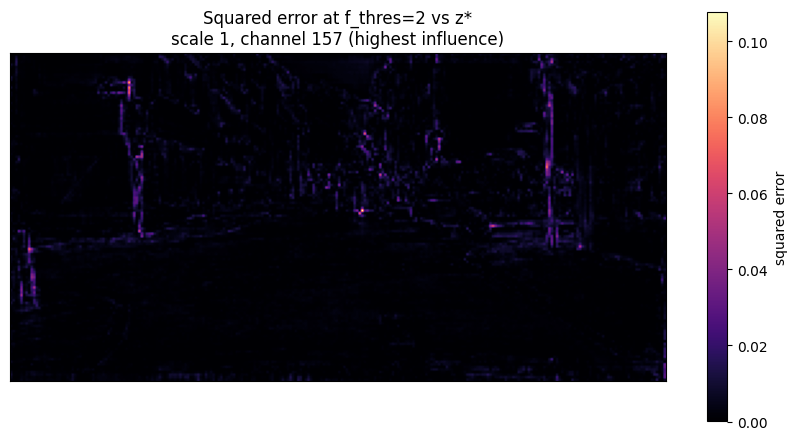

In [8]:
import matplotlib.pyplot as plt

with torch.no_grad():
    z_early, _, _ = model._forward([image_gpu, None], train_step=-1, compute_jac_loss=False, f_thres=2)

top_channel_local = scale_influence[1].argmax().item()
print(f"highest-influence channel in scale 1: local index {top_channel_local}, "
      f"influence={scale_influence[1][top_channel_local]:.4f}")

residual_map = (z_early[1][0, top_channel_local] - z_star[1][0, top_channel_local]).pow(2).cpu().numpy()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(residual_map, cmap="magma")
ax.set_title(f"Squared error at f_thres=2 vs z*\nscale 1, channel {top_channel_local} (highest influence)")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, label="squared error")
plt.tight_layout()
plt.show()

The error is not spread uniformly across the image. It concentrates in vertical structures (poles, pedestrian silhouettes) and object boundaries. This is an early hint that fine spatial detail is what the solver struggles with most in a small iteration budget, which the per-channel analysis in the next sections looks at directly.

## 9. Per-channel MSE across Broyden iterations

The main question of this notebook: run the same forward pass with `f_thres = 1, 2, ..., 27` and measure how far each channel's state is from z\* (mean squared error, averaged over the spatial dimensions) at each iteration count. A channel that converges fast should already be close to z\* at small `f_thres`; a slow one stays far from z\* for longer.

We reuse the exact same mechanism the main sweep already uses to control solver iterations (`f_thres` — the `broyden_iterations` config knob, just called directly instead of through a YAML). No new solver logic, just re-running `_forward` at each budget and comparing to the z\* saved in Section 5.

In [9]:
F_THRES_VALUES = list(range(1, config.DEQ.F_THRES + 1))  # 1..27, matching the reference z*

mse_per_scale = [[] for _ in range(4)]  # mse_per_scale[scale][i] = per-channel MSE tensor at F_THRES_VALUES[i]

with torch.no_grad():
    for ft in F_THRES_VALUES:
        z_ft, _, _ = model._forward(
            [image_gpu, None], train_step=-1, compute_jac_loss=False, f_thres=ft,
        )
        for i in range(4):
            per_channel_mse = (z_ft[i] - z_star[i]).pow(2).mean(dim=(0, 2, 3)).cpu()
            mse_per_scale[i].append(per_channel_mse)

# stack into one tensor per scale: shape (len(F_THRES_VALUES), num_channels_in_that_scale)
mse_per_scale = [torch.stack(scale_list) for scale_list in mse_per_scale]

print("f_thres values used:", F_THRES_VALUES)
for i in range(4):
    print(f"  scale {i}: mse_per_scale[{i}].shape = {tuple(mse_per_scale[i].shape)}  "
          f"| MSE at f_thres=27 (sanity check, should be ~0): {mse_per_scale[i][-1].mean().item():.2e}")

# Broyden's own early-stopping criteria (solvers.py: "if new_objective < eps: break", and the
# "no progress in the last 30 steps" check) mean the solver often reaches its converged point
# well before f_thres=27, then simply stops -- so higher f_thres values past that point return
# the *exact same* result. Check where each scale first becomes bit-identical to z*:
for i in range(4):
    exact_matches = [ft for ft, mse in zip(F_THRES_VALUES, mse_per_scale[i]) if mse.sum().item() == 0.0]
    first_exact = exact_matches[0] if exact_matches else None
    print(f"  scale {i}: first f_thres with an exact (MSE=0) match to z* = {first_exact}")

f_thres values used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
  scale 0: mse_per_scale[0].shape = (27, 88)  | MSE at f_thres=27 (sanity check, should be ~0): 0.00e+00
  scale 1: mse_per_scale[1].shape = (27, 176)  | MSE at f_thres=27 (sanity check, should be ~0): 0.00e+00
  scale 2: mse_per_scale[2].shape = (27, 352)  | MSE at f_thres=27 (sanity check, should be ~0): 0.00e+00
  scale 3: mse_per_scale[3].shape = (27, 704)  | MSE at f_thres=27 (sanity check, should be ~0): 0.00e+00
  scale 0: first f_thres with an exact (MSE=0) match to z* = 26
  scale 1: first f_thres with an exact (MSE=0) match to z* = 26
  scale 2: first f_thres with an exact (MSE=0) match to z* = 26
  scale 3: first f_thres with an exact (MSE=0) match to z* = 26


The sanity check passes (MSE at `f_thres=27` is exactly 0 for all 4 scales, as expected since that's the same computation used to define z\* itself). More usefully, all 4 scales first become bit-identical to z\* at the same iteration, **`f_thres=26`**, one step before the budget runs out. This happens because Broyden solves all 4 scales as a single concatenated vector, so its early-stopping rule (`solvers.py`: `if new_objective < eps: break`) fires for every scale at once. This one detail explains a visual quirk in the next two sections' log-scale plots: once MSE hits exactly `0.0`, it can no longer be plotted on a log axis, so the curves appear to "drop off" right at the end; that's this finding becoming visible, not missing data.

## 10. Average convergence speed per scale

Averaging the per-channel MSE within each scale gives one curve per scale, the most direct comparison against the main sweep's "scale 1 matters most" finding. If that finding has a convergence-speed explanation, scale 1 should stand out here too (either converging slower, so it benefits most from a warm start, or the opposite).

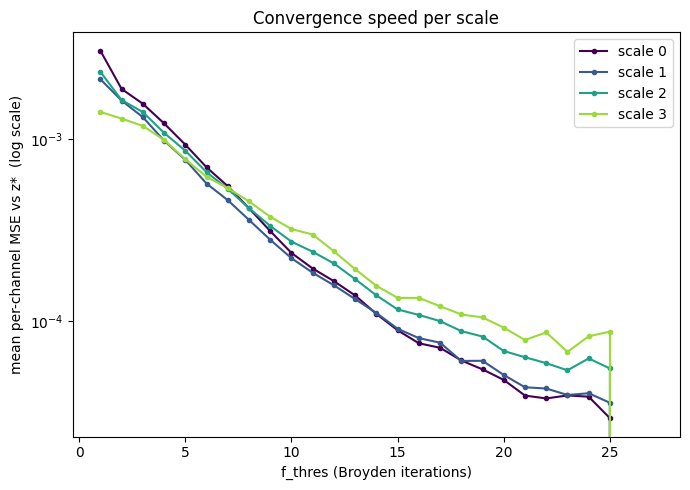

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, 4))
for i in range(4):
    avg_mse = mse_per_scale[i].mean(dim=1)  # average over channels, keep per-f_thres
    ax.plot(F_THRES_VALUES, avg_mse.numpy(), marker="o", ms=3, color=colors[i], label=f"scale {i}")

ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("mean per-channel MSE vs z*  (log scale)")
ax.set_title("Convergence speed per scale")
ax.legend()
ax.minorticks_off()
plt.tight_layout()
plt.show()

Scale 0 (finest resolution) converges fastest on average; scale 3 (coarsest) is the slowest; scales 1 and 2 sit in between. Already a first sign that **scale 1's importance for warm-starting doesn't come from it being the slowest scale to converge**. It isn't.

## 11. Convergence variance within each scale

An average can hide a lot: a scale could converge fast on average but have a handful of slow outlier channels (or the opposite). Here we plot, one panel per scale, the median channel plus the 10th-90th percentile band across channels, so we can see the spread instead of just one number. All four panels share the same y-axis so the scales are still directly comparable.

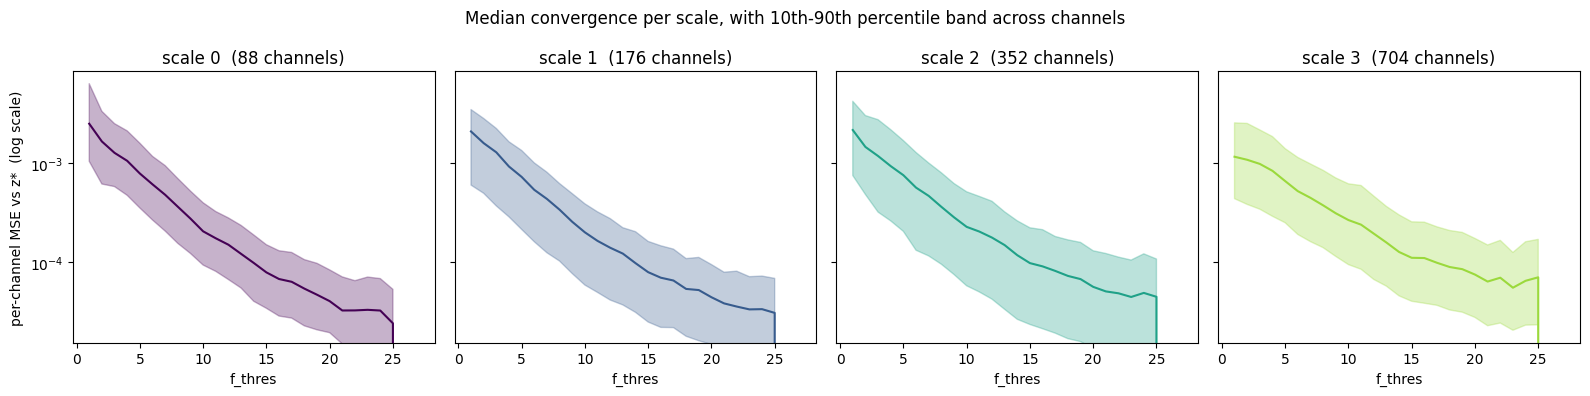

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, ax in enumerate(axes):
    mse_np = mse_per_scale[i].numpy()  # shape (len(F_THRES_VALUES), num_channels)
    p10, p50, p90 = np.percentile(mse_np, [10, 50, 90], axis=1)
    ax.plot(F_THRES_VALUES, p50, color=colors[i])
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[i], alpha=0.3)
    ax.set_yscale("log")
    ax.set_title(f"scale {i}  ({mse_per_scale[i].shape[1]} channels)")
    ax.set_xlabel("f_thres")
    ax.minorticks_off()

axes[0].set_ylabel("per-channel MSE vs z*  (log scale)")
fig.suptitle("Median convergence per scale, with 10th-90th percentile band across channels")
plt.tight_layout()
plt.show()

**Conclusion:** scale 0 has the widest channel-to-channel spread of any scale — some of its channels settle almost immediately, others lag well behind its own average. Averages alone (Section 10) hide this: "fastest scale on average" doesn't mean "every channel in it is fast."

## 12. Do slow-converging channels matter more or less?

Section 6 gave us, per channel, how much it can move the final segmentation (`contribution`). Here we ask whether that lines up with convergence speed: we use the MSE at an early budget (`f_thres=2`) as a stand-in for "how unconverged this channel still is early on," and scatter it against `contribution`, one point per channel, colored by scale.

correlation (MSE at f_thres=2  vs  contribution to final segmentation): pearson=0.755  spearman=0.844


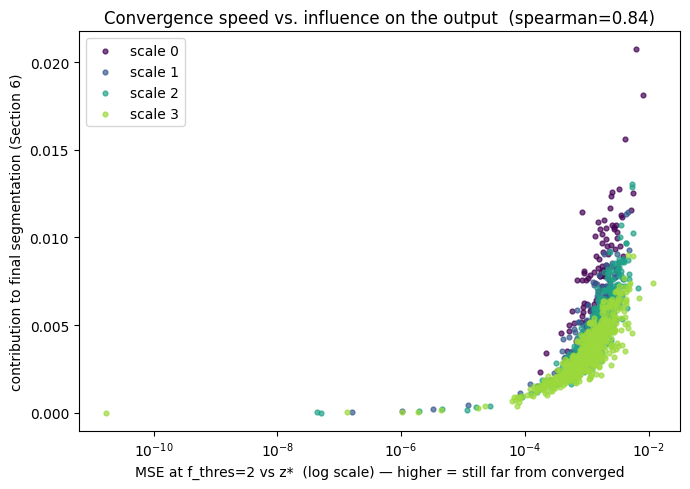

In [12]:
from scipy.stats import spearmanr

ft2_index = F_THRES_VALUES.index(2)
early_mse = torch.cat([mse_per_scale[i][ft2_index] for i in range(4)])  # concat order matches `contribution` (Sec. 6)

# Pearson (on raw values) is sensitive to the few extreme points here, since early_mse
# spans ~12 orders of magnitude; Spearman (rank-based) is a more robust summary of the trend.
pearson_r = np.corrcoef(early_mse.numpy(), contribution.numpy())[0, 1]
spearman_r, _ = spearmanr(early_mse.numpy(), contribution.numpy())
print(f"correlation (MSE at f_thres=2  vs  contribution to final segmentation): "
      f"pearson={pearson_r:.3f}  spearman={spearman_r:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    ax.scatter(early_mse[sl], contribution[sl], s=12, color=colors[i], alpha=0.7, label=f"scale {i}")

ax.set_xscale("log")
ax.set_xlabel("MSE at f_thres=2 vs z*  (log scale) — higher = still far from converged")
ax.set_ylabel("contribution to final segmentation (Section 6)")
ax.set_title(f"Convergence speed vs. influence on the output  (spearman={spearman_r:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

A strong positive correlation (Pearson 0.755, Spearman 0.844) indicates that channels that are still far from converging early on (`f_thres=2`) tend to also be the channels that matter most for the final segmentation. In other words, the slowest-to-settle channels are **not** the ones the segmentation head ignores; if anything, they're disproportionately important ones.

## 13. All 1320 features at once

Sections 10-11 summarize by scale (average, then median + spread), which is the right level for comparing to the main sweep, but it collapses away the individual channel. Here's every channel's own trajectory, with nothing summarized: one point per channel per `f_thres`, one panel per scale (scale 3 has 8x more channels than scale 0, so a single shared panel would make it look like almost everything was scale 3). Each point's height carries its value directly, so a channel with an unusual convergence speed just shows up in an unusual place rather than needing a color scale to represent it (see the closing technical notes for why a heatmap version of this was tried and dropped).

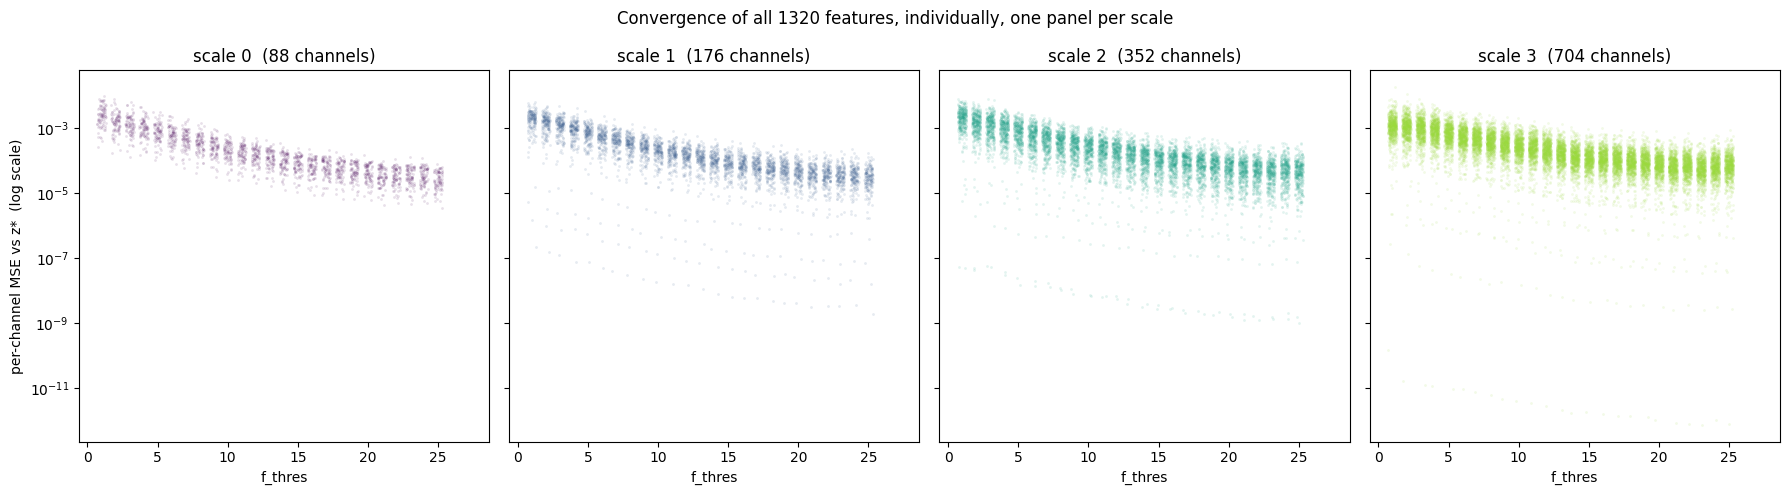

In [13]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for i, ax in enumerate(axes):
    scale_mse = mse_per_scale[i].numpy()  # (27, num_channels_in_scale_i)
    n_channels = scale_mse.shape[1]
    x = np.repeat(F_THRES_VALUES, n_channels).astype(float)
    x += rng.uniform(-0.3, 0.3, size=x.shape)  # jitter so overlapping points read as a density, not one blob
    y = scale_mse.flatten()  # row-major: matches the repeated f_thres order in x
    ax.scatter(x, y, s=4, alpha=0.12, color=colors[i], linewidths=0)
    ax.set_yscale("log")
    ax.set_title(f"scale {i}  ({n_channels} channels)")
    ax.set_xlabel("f_thres")
    ax.minorticks_off()

axes[0].set_ylabel("per-channel MSE vs z*  (log scale)")
fig.suptitle("Convergence of all 1320 features, individually, one panel per scale")
plt.tight_layout()
plt.show()

# Used again in Section 14: each channel's trajectory relative to its own f_thres=1 value.
all_mse = torch.cat([mse_per_scale[i] for i in range(4)], dim=1).numpy()  # (27, 1320), concat order matches Section 6
relative_mse = all_mse / all_mse[0:1, :]

In every scale, most channels follow a similar decay curve, plus a dispersed tail of channels that converge almost instantly (dropping to 1e-9 – 1e-11 within the first couple of iterations), the same "instant converger" channels already visible in Section 12's correlation. This heterogeneity exists inside every scale, not just in the scale-level averages from Section 10.

## 14. Distribution of convergence speed per scale

Section 13's scatter shows every point but makes it hard to compare scales at a glance. A more direct way to show "which channels converge fast, which don't" is to reduce each channel's whole trajectory to one number — **the smallest `f_thres` at which its relative MSE first drops below 10% of its `f_thres=1` value** — and scatter *that*, one point per channel, grouped by scale.

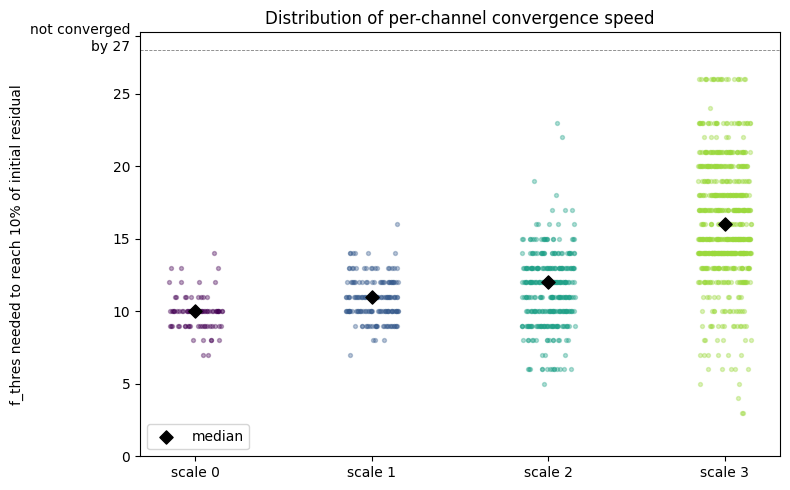

scale 0: median iters-to-converge = 10.0  | 0/88 channels never reached the threshold
scale 1: median iters-to-converge = 11.0  | 0/176 channels never reached the threshold
scale 2: median iters-to-converge = 12.0  | 0/352 channels never reached the threshold
scale 3: median iters-to-converge = 16.0  | 0/704 channels never reached the threshold


In [14]:
CONVERGE_THRESHOLD = 0.1  # relative MSE has dropped to 10% of its f_thres=1 value


def first_below(row, threshold):
    idx = np.where(row < threshold)[0]
    return F_THRES_VALUES[idx[0]] if len(idx) else np.nan


iters_to_converge = np.array(
    [first_below(relative_mse[:, c], CONVERGE_THRESHOLD) for c in range(relative_mse.shape[1])]
)
not_converged = np.isnan(iters_to_converge)
NOT_CONVERGED_Y = config.DEQ.F_THRES + 2  # plotting position for channels that never reach the threshold
plot_y = np.where(not_converged, NOT_CONVERGED_Y, iters_to_converge)

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    y = plot_y[sl]
    x = i + rng.uniform(-0.15, 0.15, size=len(y))
    ax.scatter(x, y, s=8, alpha=0.35, color=colors[i])
    ax.scatter(i, np.median(y), color="black", marker="D", s=45, zorder=5, label="median" if i == 0 else None)

ax.axhline(NOT_CONVERGED_Y - 1, color="gray", lw=0.6, ls="--")
ax.set_xticks(range(4))
ax.set_xticklabels([f"scale {i}" for i in range(4)])
ax.set_yticks(list(range(0, config.DEQ.F_THRES + 1, 5)) + [NOT_CONVERGED_Y])
ax.set_yticklabels([str(v) for v in range(0, config.DEQ.F_THRES + 1, 5)] + ["not converged\nby 27"])
ax.set_ylabel(f"f_thres needed to reach {int(CONVERGE_THRESHOLD * 100)}% of initial residual")
ax.set_title("Distribution of per-channel convergence speed")
ax.legend()
plt.tight_layout()
plt.show()

for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    n_not_converged = int(not_converged[sl].sum())
    print(f"scale {i}: median iters-to-converge = {np.nanmedian(iters_to_converge[sl]):.1f}  "
          f"| {n_not_converged}/{sl.stop - sl.start} channels never reached the threshold")

**Conclusion:** median iterations-to-10%: scale 0 = 10, scale 1 = 11, scale 2 = 12, scale 3 = 16 — matching Section 10's ranking exactly. But the more interesting part is the *spread*, not just the median: scale 0's points are tightly clustered (roughly 7-14), while scale 3's stretch all the way from single digits up to 26 (right against the "not converged" line). So scale 3 isn't just slower on average — it's where the genuinely slow-converging outlier channels live.

## Overall summary

- **Section 10 (average per scale)**: scale 0 (finest resolution) converges fastest on average, scale 3 (coarsest) slowest, with scale 1 and 2 in between.
- **Section 11 (spread within a scale)**: scale 0 also has the widest channel-to-channel spread — some of its channels settle almost immediately, others lag well behind the scale-0 average.
- **Section 13 (all 1320 channels, individually)** and **Section 14 (convergence-speed distribution)**: the spread isn't a clean scale-by-scale story — every scale has its own mix of fast and slow channels, though the *proportion* of slow ones grows from scale 0 to scale 3.
- **Section 12 (convergence speed vs. influence)**: channels that are still furthest from z\* at `f_thres=2` tend to also be higher-contribution channels (Pearson 0.76, Spearman 0.84) — the slowest-to-settle channels are not the ones the segmentation head ignores.

Contrasted against the main sweep's finding (scale 1 matters most for warm-starting), this state-level view does **not** show scale 1 as the slowest-converging scale — scale 3 is. That's a real, useful piece of evidence for the writeup: whatever makes scale 1 valuable to warm-start isn't simply "it's the scale that takes the solver longest to re-derive from scratch." The mechanism is more likely about *how much scale 1's error propagates to the other scales during fusion* (via `fullstage`) than about its own raw convergence speed. `convergence_population_analysis.ipynb` checks whether this single-image picture holds up across the full validation set.

## Technical notes

A few implementation details that don't belong in the main narrative above, but are worth keeping for the record:

- **Reproducibility check (Section 1).** Before trusting z\* as a fixed reference, GPU nondeterminism was checked directly: the same forward pass (with and without gradients) was run in separate process launches, with no special cuDNN settings, and gave bit-identical results every time. No determinism fix was needed.
- **`func(z*)` vs. `z*` (Section 7).** The first time z\* (Section 4) was compared against the output of a `spectral_radius_mode=True` call, the two didn't match, which initially looked like a reproducibility bug. The actual cause is structural, not numerical: with `spectral_radius_mode=True`, `_forward()` returns `func(z*)` (one extra application of the fixed-point map), not the raw `z*`. Re-running that call twice gave identical results both times, confirming it's a deterministic difference in what's being computed, not GPU noise.
- **Heatmap vs. scatter (Section 13).** A heatmap (channels × `f_thres`, color = MSE) was tried first for visualizing all 1320 channels at once. It stayed compressed no matter how the color scale was adjusted (fixed floor, percentiles, sorting channels by speed) because the per-channel spread is too wide for any single color mapping to represent well. The scatter plot used instead sidesteps this: each point's height carries its value directly, so it doesn't need one global color range.
- **10% vs. 1% threshold (Section 14).** A stricter 1% convergence threshold was tried first; nearly every channel only crosses that close to the exact-convergence cliff at `f_thres=26` (Section 9), which collapses the whole distribution back to one point. 10% spreads the distribution out in a way that's actually readable.